# T3 — Paso 2: Ajuste de hiperparámetros

**Grupo 01** — Aplicaciones de IA en Estructuras, UPC

Este notebook documenta cómo se eligieron los hiperparámetros de cada modelo, para cumplir
el criterio de la rúbrica de **uso justificado de hiperparámetros**.

**Método:**

- Búsqueda aleatoria (`RandomizedSearchCV`) de 20 combinaciones por modelo, dentro de los
  rangos definidos en `src/ajuste.py`.
- Cada combinación se evalúa con **validación cruzada de 5 pliegues agrupada por sismo**
  (`GroupKFold` por EQID). En cada pliegue, los sismos de validación nunca aparecen en el
  entrenamiento, igual que en la partición final.
- Se usa **solo el conjunto de entrenamiento** (322 sismos). Los 81 sismos de prueba no se
  tocan hasta la evaluación final (paso 3).

> La línea base (regresión lineal) no tiene hiperparámetros que ajustar.

**Tiempo estimado:** varios minutos por modelo, según la computadora.

In [1]:
import sys, time
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.datos import preparar_datos
from src.ajuste import ajustar, resumen_busqueda, guardar, CONSTRUCTORES, ARCHIVO_PARAMETROS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1. Datos de entrenamiento

In [2]:
train, test = preparar_datos()
del test  # se descarta aquí a propósito: el ajuste no debe ver la prueba

print(f"Entrenamiento: {len(train):,} registros de {train['EQID'].nunique()} sismos")

Entrenamiento: 9,976 registros de 322 sismos


## 2. Búsqueda por modelo

Para cada modelo se muestran las cinco mejores combinaciones. La columna **brecha**
(RMSE de validación menos RMSE de entrenamiento) mide el sobreajuste: una brecha grande
indica que el modelo memoriza los sismos de entrenamiento en lugar de generalizar.

In [3]:
busquedas = {}
for nombre in CONSTRUCTORES:
    inicio = time.time()
    busquedas[nombre] = ajustar(nombre, train)
    print(f"{nombre:18s} RMSE validación: {-busquedas[nombre].best_score_:.3f}"
          f"   ({time.time() - inicio:.0f} s)")

Random Forest      RMSE validación: 0.828   (40 s)
XGBoost            RMSE validación: 0.812   (24 s)
XGBoost monótono   RMSE validación: 0.817   (23 s)
Red neuronal       RMSE validación: 0.822   (230 s)


In [4]:
resumen_busqueda(busquedas["Random Forest"]).round(3)

,RMSE validación,desv. validación,RMSE entrenamiento,brecha,hiperparámetros
15,0.828,0.075,0.396,0.432,"{'n_estimators': 600, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}"
6,0.828,0.072,0.530,0.298,"{'n_estimators': 600, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 30}"
5,0.828,0.072,0.530,0.298,"{'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20}"
13,0.829,0.075,0.398,0.432,"{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}"
4,0.830,0.067,0.647,0.183,"{'n_estimators': 600, 'min_samples_leaf': 20, 'max_features': 0.6, 'max_depth': 10}"


In [5]:
resumen_busqueda(busquedas["XGBoost"]).round(3)

,RMSE validación,desv. validación,RMSE entrenamiento,brecha,hiperparámetros
12,0.812,0.037,0.721,0.091,"{'colsample_bytree': 0.718509402281633, 'learning_rate': 0.016406549192101497, 'max_depth': 2, 'min_child_weight': 5..."
3,0.818,0.048,0.745,0.072,"{'colsample_bytree': 0.8446612641953124, 'learning_rate': 0.010213944061855218, 'max_depth': 2, 'min_child_weight': ..."
8,0.836,0.053,0.594,0.242,"{'colsample_bytree': 0.7035119926400067, 'learning_rate': 0.07277150634170934, 'max_depth': 3, 'min_child_weight': 3..."
14,0.838,0.063,0.510,0.328,"{'colsample_bytree': 0.9705203514053395, 'learning_rate': 0.07031868485129121, 'max_depth': 5, 'min_child_weight': 5..."
18,0.840,0.062,0.549,0.292,"{'colsample_bytree': 0.6125716742746937, 'learning_rate': 0.06729596646792112, 'max_depth': 5, 'min_child_weight': 1..."


In [6]:
resumen_busqueda(busquedas["XGBoost monótono"]).round(3)

,RMSE validación,desv. validación,RMSE entrenamiento,brecha,hiperparámetros
16,0.817,0.054,0.572,0.246,"{'colsample_bytree': 0.7888859700647797, 'learning_rate': 0.014308552498147852, 'max_depth': 7, 'min_child_weight': ..."
17,0.818,0.049,0.543,0.275,"{'colsample_bytree': 0.7024273291045295, 'learning_rate': 0.011287696216458833, 'max_depth': 8, 'min_child_weight': ..."
12,0.820,0.037,0.732,0.087,"{'colsample_bytree': 0.718509402281633, 'learning_rate': 0.016406549192101497, 'max_depth': 2, 'min_child_weight': 5..."
4,0.824,0.054,0.508,0.316,"{'colsample_bytree': 0.7168578594140873, 'learning_rate': 0.029967309097101588, 'max_depth': 7, 'min_child_weight': ..."
10,0.826,0.054,0.550,0.276,"{'colsample_bytree': 0.9687496940092467, 'learning_rate': 0.01303561122512888, 'max_depth': 8, 'min_child_weight': 1..."


In [7]:
resumen_busqueda(busquedas["Red neuronal"]).round(3)

,RMSE validación,desv. validación,RMSE entrenamiento,brecha,hiperparámetros
10,0.822,0.042,0.756,0.065,"{'alpha': 0.08568869785189001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.0001238513729886094}"
13,0.823,0.041,0.761,0.062,"{'alpha': 0.01712337597316398, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.00010762979285747985}"
19,0.835,0.070,0.719,0.116,"{'alpha': 0.07556810141274425, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.00079342935945906}"
3,0.837,0.053,0.717,0.120,"{'alpha': 0.00021618942406574428, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.00010994335574766199}"
16,0.840,0.059,0.735,0.105,"{'alpha': 4.936948694960461e-05, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.00032927591344236165}"


## 3. Sensibilidad a los hiperparámetros

Si todas las combinaciones dan un RMSE parecido, el modelo es **robusto** a la elección de
hiperparámetros, lo que también es evidencia de estabilidad para el marco PCS. Si la
dispersión es grande, la elección importa y debe justificarse con más cuidado.

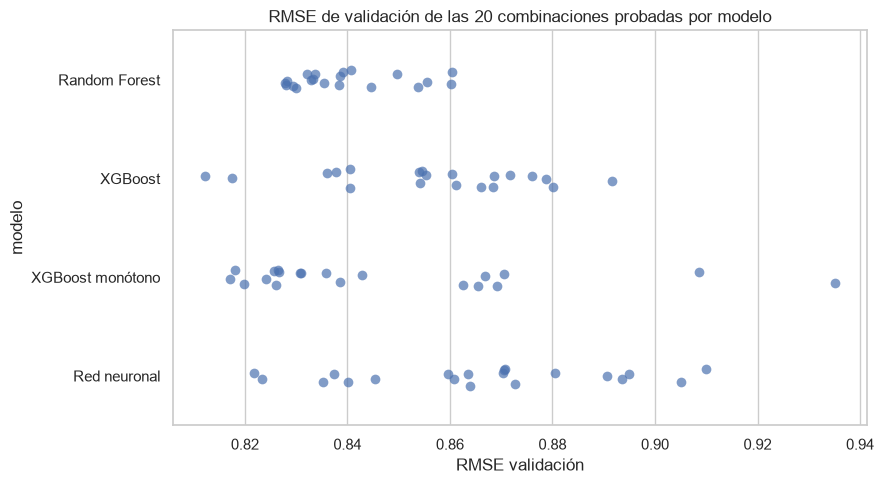

,min,median,max
modelo,,,
Random Forest,0.828,0.837,0.860
Red neuronal,0.822,0.867,0.910
XGBoost,0.812,0.858,0.892
XGBoost monótono,0.817,0.833,0.935


In [8]:
filas = []
for nombre, b in busquedas.items():
    for rmse in -b.cv_results_["mean_test_score"]:
        filas.append({"modelo": nombre, "RMSE validación": rmse})
dispersion = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(data=dispersion, x="RMSE validación", y="modelo", size=7, alpha=0.7, ax=ax)
ax.set_title("RMSE de validación de las 20 combinaciones probadas por modelo")
plt.tight_layout()
plt.savefig("../results/ajuste_sensibilidad.png", dpi=150, bbox_inches="tight")
plt.show()

dispersion.groupby("modelo")["RMSE validación"].agg(["min", "median", "max"]).round(3)

## 4. Hiperparámetros seleccionados

Se guardan en `results/mejores_hiperparametros.json`. El paso 3 los lee de ese archivo,
de modo que la evaluación final usa exactamente estos valores.

In [9]:
mejores = {nombre: b.best_params_ for nombre, b in busquedas.items()}
guardar(mejores)

for nombre, params in mejores.items():
    print(f"\n{nombre}")
    for k, v in params.items():
        k = k.replace("modelo__", "")
        print(f"   {k:20s} = {v:.4g}" if isinstance(v, float) else f"   {k:20s} = {v}")

print(f"\nGuardado en {ARCHIVO_PARAMETROS}")


Random Forest
   n_estimators         = 600
   min_samples_leaf     = 2
   max_features         = sqrt
   max_depth            = 30

XGBoost
   colsample_bytree     = 0.7185
   learning_rate        = 0.01641
   max_depth            = 2
   min_child_weight     = 5
   n_estimators         = 720
   reg_lambda           = 3.503
   subsample            = 0.6795

XGBoost monótono
   colsample_bytree     = 0.7889
   learning_rate        = 0.01431
   max_depth            = 7
   min_child_weight     = 5
   n_estimators         = 968
   reg_lambda           = 2.776
   subsample            = 0.6944

Red neuronal
   alpha                = 0.08569
   hidden_layer_sizes   = (32,)
   learning_rate_init   = 0.0001239

Guardado en C:\grupo01-pga-ml\results\mejores_hiperparametros.json


## 5. Lectura para el informe

Preguntas a responder por escrito en la sección de metodología del informe IEEE:

1. **¿Qué modelo obtuvo el menor RMSE de validación?** Comparar con la línea base
   (RMSE de prueba 0.865 en el T2, aunque no es directamente comparable porque aquella
   cifra es de prueba y estas son de validación cruzada).
2. **¿Hay sobreajuste?** Revisar la columna *brecha* de las mejores combinaciones.
   Random Forest y XGBoost suelen tener brechas grandes; si la validación sigue siendo
   buena, el sobreajuste es tolerable.
3. **¿Qué tan sensible es cada modelo a sus hiperparámetros?** Ver la figura de la
   sección 3.
4. **¿Cuánto cuesta la restricción de monotonía?** Comparar el RMSE de validación de
   XGBoost con y sin restricción.